# Q3: Feature Engineering and Regression Pipeline

This notebook builds a reproducible machine learning pipeline to predict retail store sales using feature engineering and regression models.

1. Date Feature Engineering

In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract date features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# Create binary feature
df["is_month_end"] = df["transaction_date"].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


2. Temporal Train-Test Split

In [14]:
# Sort by date
df = df.sort_values("transaction_date")

# Split index
split_index = int(len(df) * 0.8)

# Train and test sets
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


A random split is inappropriate for time-ordered data because it can leak future information into the training set. In real-world forecasting, models should only learn from past data to predict future outcomes.

3. Preprocessing Pipeline

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features and target
target = "items_sold"

X_train = train_df.drop(columns=[target, "transaction_date"])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, "transaction_date"])
y_test = test_df[target]

# Define columns
categorical_cols = ["promotion_type", "location_type", "store_size"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

4. Model Training and Evaluation

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

In [17]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395


In [18]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


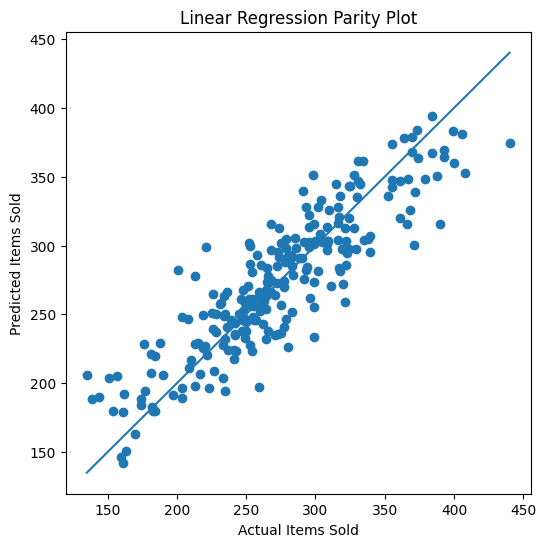

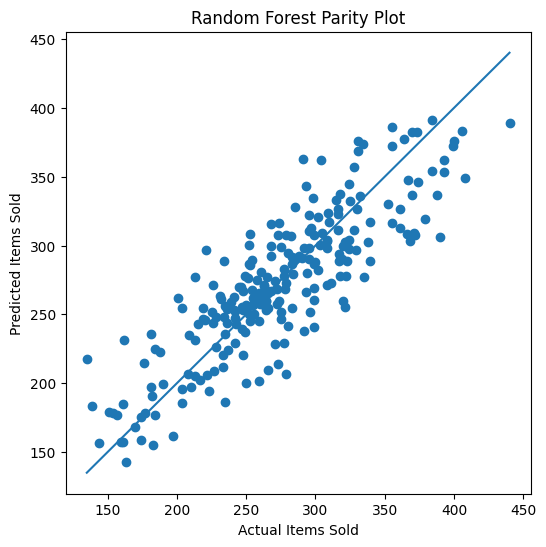

In [19]:
def parity_plot(actual, predicted, title):
    plt.figure(figsize=(6,6))
    plt.scatter(actual, predicted)
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()])
    plt.xlabel("Actual Items Sold")
    plt.ylabel("Predicted Items Sold")
    plt.title(title)
    plt.show()

parity_plot(y_test, lr_preds, "Linear Regression Parity Plot")
parity_plot(y_test, rf_preds, "Random Forest Parity Plot")

In [20]:
# Get feature names
ohe_features = rf_pipeline.named_steps["preprocessor"]\
    .named_transformers_["cat"]\
    .get_feature_names_out(categorical_cols)

all_features = list(ohe_features) + numerical_cols

# Importances
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208
11,store_id,0.054882
5,location_type_rural,0.053794
8,store_size_large,0.051113
14,competition_density,0.050805
16,month,0.037383


The top 5 most influential features are identified based on the Random Forest importance scores. These variables contribute the most toward predicting retail sales.